# 00 · Quick start

`foresight_gpu` turns a deterministic model into a **reliable probabilistic forecast** using
the Generalized Pareto Uncertainty (GPU) method. The public interface is a scikit-learn
regressor.

- `predict(X)` → point estimate (median band)
- `predict_quantiles(X)` → non-exceedance-probability bands
- `predictive_pvalues(X, y)` → where each observation falls in its forecast distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import MLPModel
from foresight_gpu.metrics.probabilistic import reliability
from foresight_gpu.utils import plot_timeseries, plot_qq

### A daily temperature record

Four years of daily mean air temperature at a mid-latitude station: a seasonal cycle from
about 7 °C in winter to 23 °C in summer. Summers are **steady**, winters are **volatile**
(cold snaps and mild spells), so the day-to-day uncertainty is ~3.5× larger in January than in
July.

The only inputs are the season (sine and cosine of the day of year). The record is synthetic,
so the true spread `sigma` is known and we can check whether GPU recovers it. The first two
years train, the last two validate.

In [2]:
START, N_YEARS = '2018-01-01', 4
rng = np.random.default_rng(0)

end = pd.Timestamp(START) + pd.DateOffset(years=N_YEARS) - pd.Timedelta(days=1)
dates = pd.date_range(START, end, freq='D')
winter = np.cos(2 * np.pi * (dates.day_of_year - 15) / 365)   # +1 mid-January, -1 mid-July

mean = 15 - 8 * winter                     # seasonal cycle [°C]
sigma = 2.25 + 1.25 * winter               # 1.0 °C in summer .. 3.5 °C in winter
y = pd.Series(mean + sigma * rng.standard_normal(dates.size), index=dates, name='T')

X = pd.DataFrame({'Sin': np.sin(2 * np.pi * dates.day_of_year / 365),
                  'Cos': np.cos(2 * np.pi * dates.day_of_year / 365)}, index=dates)

split = dates[dates.size // 2]
train, val = dates < split, dates >= split
X_train, y_train, X_val, y_val = X[train], y[train], X[val], y[val]
print('train', X_train.shape, '| validation', X_val.shape)

train (730, 2) | validation (731, 2)


### Fit and predict

The forward model is a small MLP. Its weights are bounded, so it is told the scale of the
target through `output_scale` / `output_offset` (a plain hyperparameter: set it again with
`set_params` if you refit on a target of a different magnitude).

`Q` are the non-exceedance probabilities of the band edges: `0.05` is the value the
observation should fall below 5% of the time.

In [3]:
model = MLPModel(n_hidden=3, output_scale=y_train.std(), output_offset=y_train.mean())
gpu = GPURegressor(model=model, metric='mae', population=600, n_iter=150, random_state=0)
gpu.fit(X_train, y_train)

Q = [0.01, 0.05, 0.25, 0.45, 0.55, 0.75, 0.95, 0.99]
point = gpu.predict(X_val)                          # median band
bands = gpu.predict_quantiles(X_val, quantiles=Q)   # one column per level in Q
pvalues = gpu.predictive_pvalues(X_val, y_val)
print('validation reliability alpha =', round(reliability(pvalues), 3))

validation reliability alpha = 0.969


### The forecast, with its uncertainty

Each shade is a non-exceedance band: the observation should fall inside `45-55%` a tenth of
the time, inside `5-95%` (everything but the lightest shades) nine times in ten.

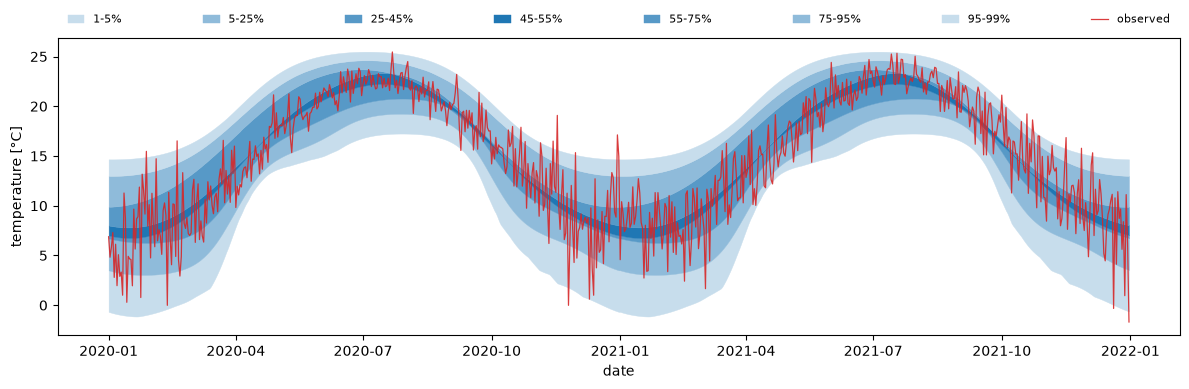

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_timeseries(bands, Q, observed=y_val, index=y_val.index, ax=ax, color='C0')
ax.set_xlabel('date')
ax.set_ylabel('temperature [°C]')
fig.tight_layout()